In [1]:
import numpy as np
import polars as pl

In [2]:
df = pl.read_csv('data_neural_network.csv')

Nas camadas ocultas será utilizado uma função de ativação, ReLU ou Tanh. Na camada de saída, devemos usar uma função que sirva para regressão como uma ativação linear para valores contínuos.
A função de custo para valores contínuos, regressão, usaremos o Erro Quadrático Médio.
E teremos que usar um otimizador como Adam ou SGD. É uma rede neural de regressão multiple-output pois queremos encontrar a energia e a composição e talvez outras grandezas a partir da densidade.

In [3]:
df

TRIG,density,composition,energy,density_normalized
str,f64,str,f64,f64
"""TRIG65""",0.35,"""Photon""",1.0000e14,0.001325
"""TRIG29""",3.76,"""Proton""",2.1500e15,0.014233
"""TRIG54""",20.14,"""Iron""",4.6400e15,0.076239
"""TRIG27""",0.05,"""Iron""",1.0000e14,0.000189
"""TRIG68""",1.2,"""Photon""",4.6400e14,0.004543
"""TRIG28""",2.53,"""Proton""",1.0000e15,0.009577
"""TRIG58""",9.49,"""Iron""",4.6400e15,0.035924
"""TRIG27""",1.18,"""Proton""",4.6400e14,0.004467
"""TRIG47""",10.27,"""Photon""",1.0000e15,0.038876


In [4]:
# Excluir a coluna density que não está normalizada
df = df.drop('density')
# Conversão de strings para números
mapper = {
    'Photon':-1,
    'Proton':float(np.log(1)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,101):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df = df.with_columns(
    pl.col('composition').map_dict(mapper, default=None),
    pl.col('TRIG').map_dict(trigs, default=None)
    )

In [5]:
df_grouped = df.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("density_normalized").first()
])

In [6]:
df_neural = df_grouped.pivot(
    values="density_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)

#df_final = df_pivoted.select(
#    ["composition", "energy"] + [f"{i}" for i in range(1, 101)]
#)
#df_final

In [7]:
df_neural

energy,composition,28,12,25,76,4,77,11,36,8,86,71,31,43,96,27,3,90,57,51,93,80,34,94,83,64,6,81,32,15,88,33,63,19,17,44,…,60,92,18,45,1,53,5,84,98,39,74,61,37,78,23,10,7,21,29,73,56,30,95,46,75,13,72,42,59,68,16,67,38,35,2,99,47
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0000e15,0.0,0.009577,0.004656,0.019571,0.018738,0.005451,0.014347,0.003748,0.040807,0.004202,0.011546,0.00511,0.005224,0.018208,0.007117,0.014725,0.005186,0.00424,0.042548,0.00636,0.005035,0.00458,0.024984,0.005262,0.0067,0.025287,0.006814,0.003937,0.008139,0.00988,0.006965,0.015445,0.016315,0.005565,0.009047,0.040012,…,0.005565,0.00318,0.006511,0.109172,0.002574,0.019041,0.005792,0.009009,0.004997,0.009123,0.014347,0.006095,0.024795,0.008858,0.010448,0.002726,0.005224,0.004921,0.007344,0.010296,0.105992,0.004505,0.005792,0.10709,0.019079,0.006662,0.007495,0.01094,0.010107,0.013476,0.009956,0.026725,0.015445,0.041526,0.003331,0.003558,0.038687
2.1500e15,0.0,0.022751,0.011583,0.040883,0.039066,0.012871,0.034675,0.007154,0.087784,0.009501,0.023129,0.010334,0.012227,0.042813,0.014536,0.031192,0.009956,0.008214,0.086005,0.014158,0.009009,0.010561,0.058864,0.012378,0.01518,0.057955,0.014006,0.008517,0.018662,0.021766,0.014574,0.030511,0.034031,0.012871,0.020593,0.085967,…,0.013514,0.007874,0.014271,0.232578,0.006814,0.043268,0.012757,0.02029,0.010183,0.018851,0.032101,0.012151,0.058258,0.022675,0.02453,0.005792,0.012492,0.010334,0.014233,0.025097,0.232842,0.011318,0.013211,0.240868,0.040958,0.015445,0.01499,0.022296,0.023545,0.033274,0.021463,0.056895,0.032176,0.088882,0.007987,0.008669,0.08733
4.6400e15,4.025352,0.023394,0.011205,0.038952,0.039293,0.012,0.033047,0.007987,0.081879,0.010561,0.021312,0.010183,0.012151,0.039899,0.014763,0.034448,0.010561,0.00829,0.077677,0.013022,0.009615,0.010524,0.052883,0.013135,0.015634,0.053867,0.012454,0.008063,0.020063,0.023205,0.015672,0.033274,0.032025,0.010675,0.020176,0.081084,…,0.014006,0.008669,0.015482,0.199379,0.007003,0.039369,0.01465,0.018511,0.011129,0.017867,0.03316,0.010561,0.052996,0.022145,0.021539,0.0067,0.011205,0.010637,0.014006,0.023545,0.184767,0.010713,0.01446,0.196086,0.041905,0.014801,0.016202,0.023962,0.022713,0.029564,0.022334,0.050271,0.031571,0.082258,0.008934,0.008669,0.077526
1.0000e14,-1.0,0.000303,0.000189,0.000454,0.000719,0.000265,0.000492,0.000227,0.00106,0.000189,0.000416,0.000189,0.000151,0.000454,0.000151,0.000341,0.000114,0.000038,0.000795,0.000151,0.000189,0.000151,0.000606,0.000189,0.000227,0.000719,0.000227,0.000076,0.000416,0.000265,0.000151,0.000492,0.000265,0.000038,0.000227,0.001022,…,0.000227,0.000114,0.000341,0.002953,0.000076,0.000606,0.000265,0.000227,0.000151,0.000492,0.000492,0.000076,0.000946,0.000379,0.000379,0.000038,0.000114,0.000379,0.000151,0.000114,0.00265,0.000114,0.000076,0.002763,0.000568,0.000227,0.000189,0.000265,0.000492,0.000227,0.000189,0.000795,0.000606,0.001249,0.000114,0.000114,0.00106
2.1500e15,-1.0,0.029602,0.01446,0.05364,0.054359,0.017413,0.038233,0.010902,0.11133,0.012681,0.026157,0.013552,0.01446,0.054813,0.019533,0.040542,0.012076,0.009236,0.118371,0.016997,0.012719,0.013211,0.076996,0.016542,0.021463,0.07499,0.017299,0.011053,0.024681,0.029526,0.019987,0.042246,0.043798,0.013893,0.025741,0.116175,…,0.017375,0.010031,0.019798,0.315517,0.008366,0.052239,0.016467,0.025741,0.012757,0.026574,0.041223,0.015558,0.073324,0.028542,0.027937,0.007306,0.015028,0.012303,0.018738,0.027861,0.314078,0.012643,0.017299,0.316501,0.056138,0.016883,0.019154,0.029299,0.028429,0.039634,0.027596,0.072113,0.040088,0.120756,0.009653,0.010637,0.11398
2.1500e14,0.0,0.001136,0.000606,0.002574,0.001893,0.000757,0.002196,0.000492,0.005224,0.000454,0.001438,0.000833,0.000681,0.002006,0.00106,0.001931,0.000681,0.000454,0.005035,0.00

In [8]:
# Log da energia
    
df_neural = df_neural.with_columns(
      ((pl.col('energy').log10()))
    )
df_neural

energy,composition,28,12,25,76,4,77,11,36,8,86,71,31,43,96,27,3,90,57,51,93,80,34,94,83,64,6,81,32,15,88,33,63,19,17,44,…,60,92,18,45,1,53,5,84,98,39,74,61,37,78,23,10,7,21,29,73,56,30,95,46,75,13,72,42,59,68,16,67,38,35,2,99,47
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
15.0,0.0,0.009577,0.004656,0.019571,0.018738,0.005451,0.014347,0.003748,0.040807,0.004202,0.011546,0.00511,0.005224,0.018208,0.007117,0.014725,0.005186,0.00424,0.042548,0.00636,0.005035,0.00458,0.024984,0.005262,0.0067,0.025287,0.006814,0.003937,0.008139,0.00988,0.006965,0.015445,0.016315,0.005565,0.009047,0.040012,…,0.005565,0.00318,0.006511,0.109172,0.002574,0.019041,0.005792,0.009009,0.004997,0.009123,0.014347,0.006095,0.024795,0.008858,0.010448,0.002726,0.005224,0.004921,0.007344,0.010296,0.105992,0.004505,0.005792,0.10709,0.019079,0.006662,0.007495,0.01094,0.010107,0.013476,0.009956,0.026725,0.015445,0.041526,0.003331,0.003558,0.038687
15.332438,0.0,0.022751,0.011583,0.040883,0.039066,0.012871,0.034675,0.007154,0.087784,0.009501,0.023129,0.010334,0.012227,0.042813,0.014536,0.031192,0.009956,0.008214,0.086005,0.014158,0.009009,0.010561,0.058864,0.012378,0.01518,0.057955,0.014006,0.008517,0.018662,0.021766,0.014574,0.030511,0.034031,0.012871,0.020593,0.085967,…,0.013514,0.007874,0.014271,0.232578,0.006814,0.043268,0.012757,0.02029,0.010183,0.018851,0.032101,0.012151,0.058258,0.022675,0.02453,0.005792,0.012492,0.010334,0.014233,0.025097,0.232842,0.011318,0.013211,0.240868,0.040958,0.015445,0.01499,0.022296,0.023545,0.033274,0.021463,0.056895,0.032176,0.088882,0.007987,0.008669,0.08733
15.666518,4.025352,0.023394,0.011205,0.038952,0.039293,0.012,0.033047,0.007987,0.081879,0.010561,0.021312,0.010183,0.012151,0.039899,0.014763,0.034448,0.010561,0.00829,0.077677,0.013022,0.009615,0.010524,0.052883,0.013135,0.015634,0.053867,0.012454,0.008063,0.020063,0.023205,0.015672,0.033274,0.032025,0.010675,0.020176,0.081084,…,0.014006,0.008669,0.015482,0.199379,0.007003,0.039369,0.01465,0.018511,0.011129,0.017867,0.03316,0.010561,0.052996,0.022145,0.021539,0.0067,0.011205,0.010637,0.014006,0.023545,0.184767,0.010713,0.01446,0.196086,0.041905,0.014801,0.016202,0.023962,0.022713,0.029564,0.022334,0.050271,0.031571,0.082258,0.008934,0.008669,0.077526
14.0,-1.0,0.000303,0.000189,0.000454,0.000719,0.000265,0.000492,0.000227,0.00106,0.000189,0.000416,0.000189,0.000151,0.000454,0.000151,0.000341,0.000114,0.000038,0.000795,0.000151,0.000189,0.000151,0.000606,0.000189,0.000227,0.000719,0.000227,0.000076,0.000416,0.000265,0.000151,0.000492,0.000265,0.000038,0.000227,0.001022,…,0.000227,0.000114,0.000341,0.002953,0.000076,0.000606,0.000265,0.000227,0.000151,0.000492,0.000492,0.000076,0.000946,0.000379,0.000379,0.000038,0.000114,0.000379,0.000151,0.000114,0.00265,0.000114,0.000076,0.002763,0.000568,0.000227,0.000189,0.000265,0.000492,0.000227,0.000189,0.000795,0.000606,0.001249,0.000114,0.000114,0.00106
15.332438,-1.0,0.029602,0.01446,0.05364,0.054359,0.017413,0.038233,0.010902,0.11133,0.012681,0.026157,0.013552,0.01446,0.054813,0.019533,0.040542,0.012076,0.009236,0.118371,0.016997,0.012719,0.013211,0.076996,0.016542,0.021463,0.07499,0.017299,0.011053,0.024681,0.029526,0.019987,0.042246,0.043798,0.013893,0.025741,0.116175,…,0.017375,0.010031,0.019798,0.315517,0.008366,0.052239,0.016467,0.025741,0.012757,0.026574,0.041223,0.015558,0.073324,0.028542,0.027937,0.007306,0.015028,0.012303,0.018738,0.027861,0.314078,0.012643,0.017299,0.316501,0.056138,0.016883,0.019154,0.029299,0.028429,0.039634,0.027596,0.072113,0.040088,0.120756,0.009653,0.010637,0.11398
14.332438,0.0,0.001136,0.000606,0.002574,0.001893,0.000757,0.002196,0.000492,0.005224,0.000454,0.001438,0.000833,0.000681,0.002006,0.00106,0.001931,0.000681,0.000454,0.005035,0.000833,0.000

In [9]:
df.filter((pl.col('composition') == 0.0) & (pl.col('energy') == 1.0000e15))

TRIG,composition,energy,density_normalized
i64,f64,f64,f64
28,0.0,1.0000e15,0.009577
98,0.0,1.0000e15,0.004997
53,0.0,1.0000e15,0.019041
15,0.0,1.0000e15,0.00988
14,0.0,1.0000e15,0.008669
11,0.0,1.0000e15,0.003748
86,0.0,1.0000e15,0.011546
68,0.0,1.0000e15,0.013476
51,0.0,1.0000e15,0.00636


In [10]:
columns = ['energy','composition']
y = df_neural.select(columns)
x = df_neural.select(pl.exclude(columns))

x = np.array(x)
y = np.array(y)

In [11]:
# Criação do modelo

import torch
import torch.nn as nn
import torch.optim as optim

# Arquitetura

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
    
        # Camadas
        self.hidden1 = nn.Linear(input_size, 64) # Primeira camada oculta
        self.hidden2 = nn.Linear(64,32) # Segunda camada oculta
        self.output = nn.Linear(32,2) # Camada de saída com 2 valores contínuos

    # Feed-forward com ativação ReLU
    def forward(self,x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = self.output(x)
        return x


input_size = 100
model = NeuralNetwork(input_size)

# Função perda - Erro quadrático médio

criterion = nn.MSELoss() 

# Otimizador Adam
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [12]:
# Treinamento do modelo

loss_list = []

x_train_tensor = torch.tensor(x, dtype= torch.float32)
y_train_tensor = torch.tensor(y, dtype= torch.float32)

epochs = 5000

for epoch in range(epochs):
    # Entra no modo de treino
    model.train()
    # Zera o gradiente
    optimizer.zero_grad()
    # Faz a predição
    outputs = model(x_train_tensor)
    # Calcula o erro
    loss = criterion(outputs, y_train_tensor)
    loss_list.append(loss.item())
    # Retropropagação
    loss.backward()
    # Atualiza os parâmetros
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/5000], Loss: 56.3785
Epoch [200/5000], Loss: 9.8963
Epoch [300/5000], Loss: 2.3577
Epoch [400/5000], Loss: 2.3110
Epoch [500/5000], Loss: 2.2655
Epoch [600/5000], Loss: 2.2453
Epoch [700/5000], Loss: 2.2332
Epoch [800/5000], Loss: 2.2137
Epoch [900/5000], Loss: 2.1989
Epoch [1000/5000], Loss: 2.1890
Epoch [1100/5000], Loss: 2.1830
Epoch [1200/5000], Loss: 2.1791
Epoch [1300/5000], Loss: 2.1749
Epoch [1400/5000], Loss: 2.1707
Epoch [1500/5000], Loss: 2.1666
Epoch [1600/5000], Loss: 2.1625
Epoch [1700/5000], Loss: 2.1505
Epoch [1800/5000], Loss: 2.1421
Epoch [1900/5000], Loss: 2.1344
Epoch [2000/5000], Loss: 2.1250
Epoch [2100/5000], Loss: 2.0825
Epoch [2200/5000], Loss: 2.0114
Epoch [2300/5000], Loss: 1.8897
Epoch [2400/5000], Loss: 1.7296
Epoch [2500/5000], Loss: 1.5592
Epoch [2600/5000], Loss: 1.3877
Epoch [2700/5000], Loss: 1.3123
Epoch [2800/5000], Loss: 1.2551
Epoch [2900/5000], Loss: 1.2105
Epoch [3000/5000], Loss: 1.1703
Epoch [3100/5000], Loss: 1.1367
Epoch [3200/5000

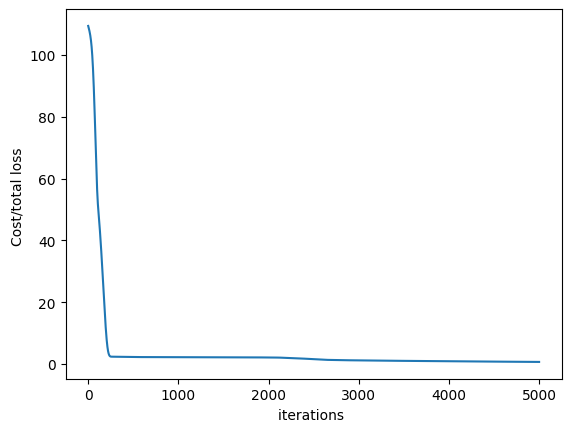

In [13]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.xlabel("iterations ")
plt.ylabel("Cost/total loss ")
plt.show()

In [22]:
# Avaliação do modelo

model.eval()

# Previsão

teste = np.random.random_sample(size = (1,100))

input_tensor = torch.tensor(teste, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    prediction = model(input_tensor)


In [23]:
print(prediction)

tensor([[[ 59.8165, 973.8930]]])
